# Project: Ecommerce Sales Analysis

### 1. Load Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_dataset.csv")

df.head()

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0


### 2. Check Data Types

In [3]:
df.dtypes

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object

### 3. Drop Irrelevant Columns

In [4]:
df.drop(columns=["Latitude", "Longtitude"], inplace=True)

df.head()

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN


### 4. Rename Columns

In [5]:
df.rename(columns={
    "City Code": "City",
    "Order Priority Code": "Order Priority"
}, inplace=True)

df.head()

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN


### 5. Check Duplicate Rows

In [6]:
df.duplicated().sum()

np.int64(6)

### 6. Drop Duplicate Records

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

### 7. Check Missing / Null Values

In [9]:
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64

### 8. Fill Missing Value

In [29]:
df["City"] = df["City"].fillna(df["City"].mode()[0])

df["Order Priority"] = df["Order Priority"].fillna(
    df["Order Priority"].mode()[0]
)

In [30]:
df.isnull().sum()

order_id          0
product           0
category          0
price             0
quantity          0
payment_method    0
date              0
total             0
Month             0
Discount          0
City              0
Order Priority    0
dtype: int64

   ## Exploratory Data Analysis

### 1. Top 5 Best Selling Products

In [11]:
top_products = (
    df.groupby("product")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_products

product
Watch         256
Mobile        230
Headphones    227
Bag           189
Shoes         188
Name: quantity, dtype: int64

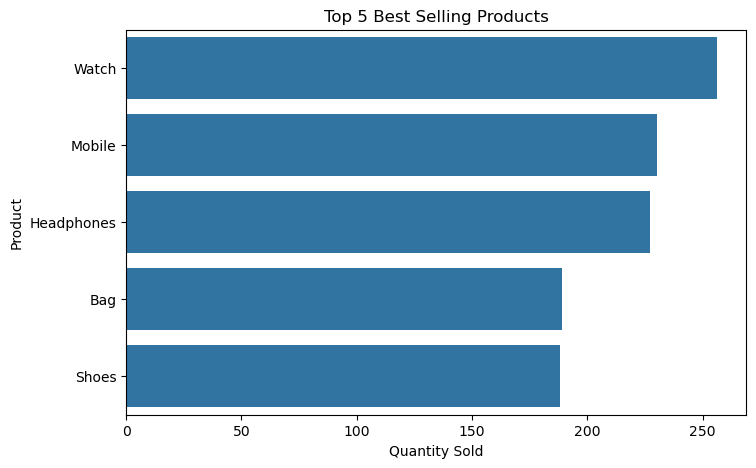

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 5 Best Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

***Observation: Watch is the best-selling product with 256 units sold, followed by Mobile and Headphones. Bag and Shoes also have strong demand among customers.***

### 2. Payment Method Distribution

In [17]:
payment_counts = df["payment_method"].value_counts()

payment_counts

payment_method
JazzCash       112
Credit Card    107
Easypaisa      105
COD             97
Debit Card      79
Name: count, dtype: int64

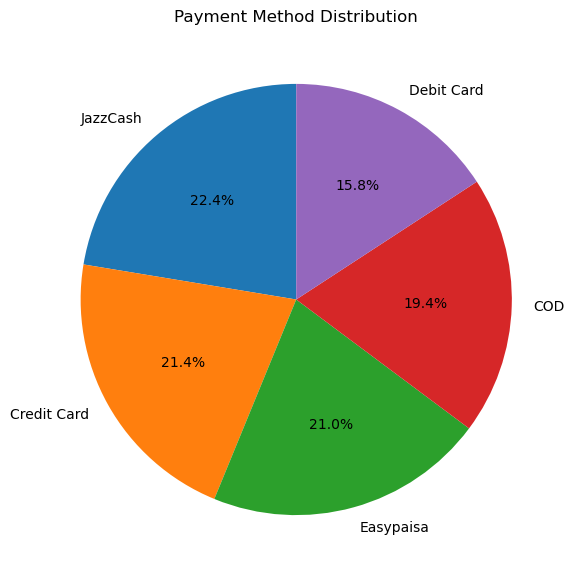

In [18]:
plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")
plt.show()

***Observation: JazzCash is the most commonly used payment method, followed by Credit Card and Easypaisa. Debit Card has the lowest number of transactions among the available payment methods.***

### 3. Month-wise Sales

In [19]:
monthly_sales = df.groupby("Month")["total"].sum()

monthly_sales

Month
April        6275753.74
August       2557288.54
December     3952563.75
February     5545040.22
January      6238414.59
July         2688475.62
June         2860920.11
March        6711119.66
May          5909845.92
November     2805153.37
October      3139444.82
September    2515916.08
Name: total, dtype: float64

In [20]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("Month")["total"]
    .sum()
    .reindex(month_order)
)

monthly_sales

Month
January      6238414.59
February     5545040.22
March        6711119.66
April        6275753.74
May          5909845.92
June         2860920.11
July         2688475.62
August       2557288.54
September    2515916.08
October      3139444.82
November     2805153.37
December     3952563.75
Name: total, dtype: float64

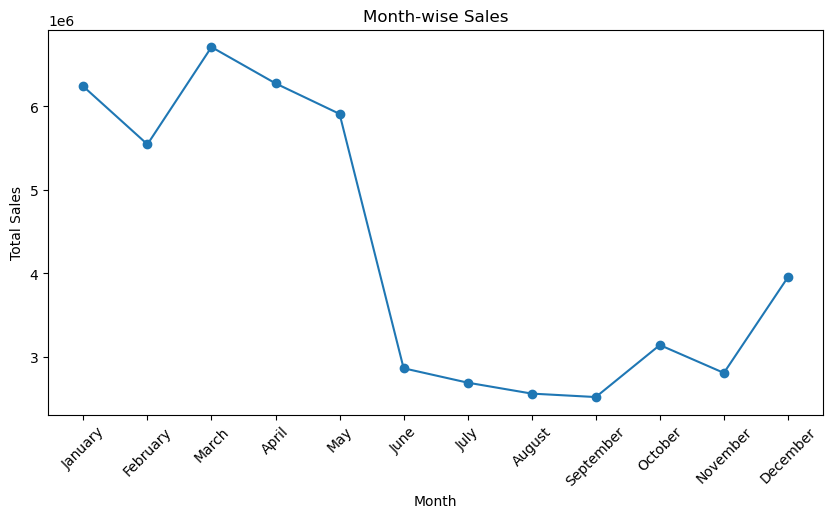

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

***Observation: Sales are highest in March, with total sales of approximately 6.71 million. Sales decline significantly from June to September, with September showing the lowest sales. Sales start recovering from October and increase again in December.***

### 4. City-wise Sales

In [23]:
city_mapping = {
    1: "Karachi",
    2: "Lahore",
    3: "Islamabad",
    4: "Faisalabad",
    5: "Quetta",
    6: "Peshawar"
}

df["City"] = df["City"].map(city_mapping)

In [24]:
df["City"].value_counts()

City
Lahore        155
Quetta         97
Islamabad      77
Peshawar       71
Faisalabad     52
Karachi        48
Name: count, dtype: int64

In [25]:
city_sales = (
    df.groupby("City")["total"]
    .sum()
    .sort_values(ascending=True)
)

city_sales

City
Karachi        5060916.14
Peshawar       6194016.19
Faisalabad     6318998.97
Islamabad      8028811.58
Quetta         9488620.43
Lahore        16108573.11
Name: total, dtype: float64

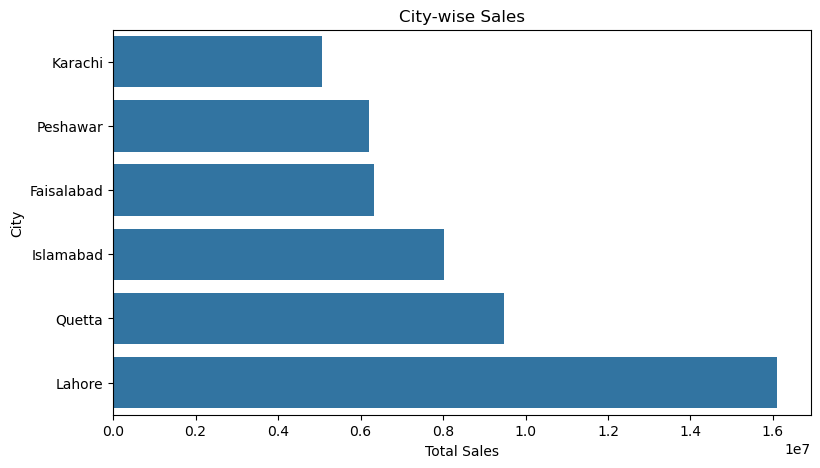

In [26]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title("City-wise Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.show()

***Observation: Lahore has the highest sales with approximately 14.67 million, followed by Quetta and Islamabad. Karachi has the lowest sales among the six cities, with approximately 5.06 million.***

### 5. Monthly Sales by Category

In [27]:
monthly_category_sales = (
    df.groupby(["Month", "category"])["total"]
    .sum()
    .unstack()
    .reindex(month_order)
)

monthly_category_sales

category,Accessories,Electronics,Fashion
Month,,,
January,2745729.82,1855039.15,1637645.62
February,1178881.69,1929360.80,2436797.73
March,2749630.71,2457415.74,1504073.21
April,2387980.38,2265079.20,1622694.16
May,1240740.21,2352232.89,2316872.82
June,1421673.13,657353.10,781893.88
July,961408.72,1218489.97,508576.93
August,521529.94,881950.11,1153808.49
September,849152.91,952931.97,713831.20


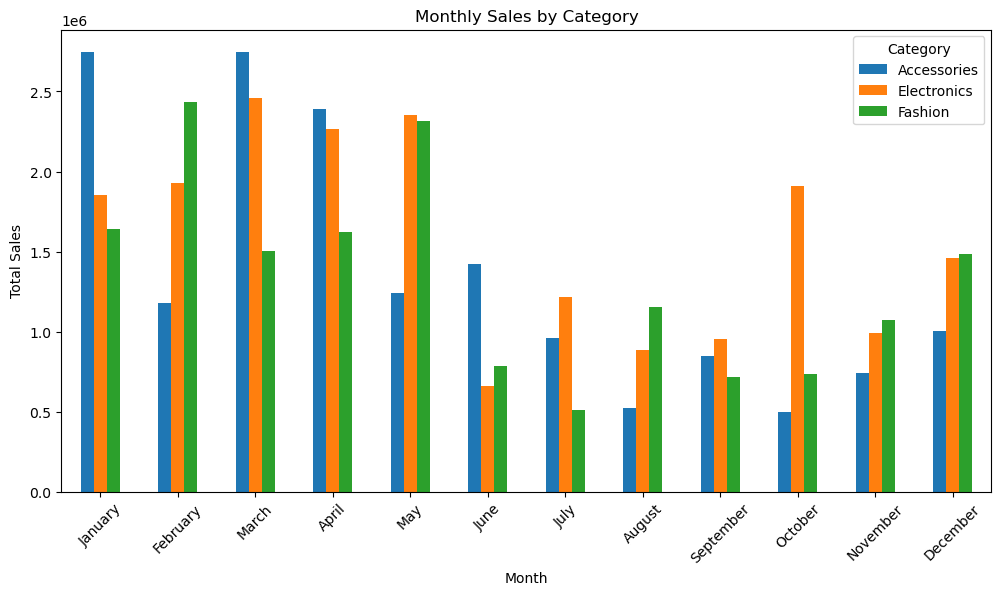

In [28]:
monthly_category_sales.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.show()

***Observation: The sales performance of categories varies across different months. Accessories perform particularly well in January and March, Electronics show strong performance in several months, while Fashion has higher sales in February, May, August, November, and December. This indicates that customer demand varies by category and month.***

## Conclusion

***The e-commerce sales analysis provides useful insights into products, payment methods, monthly sales, cities, and product categories. Watch is the best-selling product based on quantity sold, followed by Mobile and Headphones. JazzCash is the most commonly used payment method, while Debit Card has the lowest usage. Monthly sales vary throughout the year, with March showing the highest sales and September showing the lowest sales. Lahore generates the highest city-wise sales, while Karachi has the lowest sales among the analyzed cities. The monthly category analysis also shows that sales performance varies across categories and months, indicating different customer demand patterns. Overall, these insights can help the business focus on high-demand products, improve marketing strategies, and target cities and months with greater sales potential.***
